# Investigando a Esquistossomose: Onde a falta de esgoto e a água se encontram?

## O que este projeto faz?
Nós cruzamos dados do governo sobre saúde, tamanho das cidades, imagens de satélite sobre acúmulo de água e a situação do esgoto para responder a uma pergunta: Quais características fazem uma cidade se tornar um polo de transmissão da esquistossomose (doença do caramujo)?

## Por que não usamos uma matemática simples (como uma linha de tendência)?
Porque a saúde pública não funciona em linha reta. Ter muita água limpa em uma grande represa de usina hidrelétrica não causa a doença. O perigo real acontece quando juntamos três coisas: uma cidade pequena, água parada e falta de esgoto. Para achar esse padrão dinâmico, usamos a ajuda da Inteligência Artificial.

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

# ==============================================================================
# CONFIGURANDO AS PASTAS DOS ARQUIVOS
# ==============================================================================
# Aqui dizemos ao Python onde estão guardadas as nossas planilhas e dados
SINAN_PATH = Path(r"C:\Users\anapd\Downloads\sinan_esqu_unsup.parquet")
MAPBIOMAS_PATH = Path(r"C:\Users\anapd\Downloads\STATISTICS_MAPBIOMAS_AGUA_COL4_CITY-STATE-BIOME-SUB_BASINS.xlsx")
POP_MUNI_PATH = Path(r"C:\Users\anapd\Downloads\populacao_municipio.csv")
SANEAMENTO_PATH = Path(r"C:\Users\anapd\Downloads\br_mdr_snis_municipio_agua_esgoto.csv\br_mdr_snis_municipio_agua_esgoto.csv")

# Período de tempo que escolhemos para estudar: 2011 até 2014
ANO_INICIO = 2011
ANO_FIM = 2014

print(f"Tudo pronto! Vamos analisar os dados entre {ANO_INICIO} e {ANO_FIM}.")

Tudo pronto! Vamos analisar os dados entre 2011 e 2014.


# 1. Buscando os casos reais da doença (SINAN)
Aqui nós abrimos os dados do Ministério da Saúde. Para não inflar os números com suspeitas falsas, aplicamos um filtro rigoroso: só contamos as pessoas que fizeram o exame de fezes e o laboratório confirmou que realmente encontraram os ovos do verme da esquistossomose. Depois, organizamos quantos casos aconteceram por cidade em cada ano.

In [16]:
print("1/5 - Carregando dados de saúde (SINAN)...")
df_sinan = pd.read_parquet(SINAN_PATH)

# Ajustando as datas para o formato padrão do computador
df_sinan["DT_NOTIFIC"] = pd.to_datetime(df_sinan["DT_NOTIFIC"])
df_sinan["ano"] = df_sinan["DT_NOTIFIC"].dt.year

# Filtro: Só vale quem teve exame de fezes POSITIVO e dentro dos anos do nosso estudo
casos_filtrados = df_sinan[
    (pd.to_numeric(df_sinan["AN_QUALI"], errors="coerce") == 1) &
    (df_sinan["ano"].between(ANO_INICIO, ANO_FIM))
].copy()

# Padronizando o código das cidades para ficar mais fácil juntar as planilhas depois
casos_filtrados["code_muni"] = casos_filtrados["ID_MUNICIP"].astype(str).str[:6]

# Somando quantos casos positivos cada cidade teve por ano
casos_anuais = casos_filtrados.groupby(["code_muni", "ano"]).size().reset_index(name="casos")
print(f"-> Sucesso! Dados de saúde processados.")

1/5 - Carregando dados de saúde (SINAN)...
-> Sucesso! Dados de saúde processados.


# 2. Medindo a água por satélite (MapBiomas)
Nesta etapa, usamos dados de satélite que medem o tamanho dos corpos d'água de cada município.

Porém, fizemos um ajuste importante: grandes lagos de hidrelétricas ou áreas de mineração não transmitem a doença, porque a água ali é profunda e as pessoas não costumam entrar nela no dia a dia. Criamos uma nova medida chamada açudes_canais_ha, que ignora essas grandes represas e foca apenas na água pequena de fazenda, canais de irrigação e pequenos açudes rurais, que é onde o caramujo gosta de viver e onde as pessoas têm contato direto com a água.

In [17]:
print("2/5 - Carregando dados de satélite (MapBiomas)...")
agua_tipo = pd.read_excel(MAPBIOMAS_PATH, sheet_name="WATER_CITY_TYPE")

# Ajustando o código das cidades e filtrando os anos certos
agua_tipo["code_muni"] = agua_tipo["code"].astype(str).str[:6]
agua_filtrada = agua_tipo[agua_tipo["year"].between(ANO_INICIO, ANO_FIM)].copy()

# Calculando a média de água que cada cidade teve no período (para evitar distorções de secas ou enchentes)
agua_muni = (
    agua_filtrada.groupby(["code_muni", "municipality", "state"])
    .agg(
        natural_ha=("natural_area_ha", "mean"),
        anthropic_ha=("anthropic_area_ha", "mean"),
        mining_ha=("mining_area_ha", "mean"),
        hydro_ha=("hydroelectric_area_ha", "mean")
    )
    .reset_index()
)

# Subtraindo as hidrelétricas e a mineração para sobrar só os pequenos açudes e canais
agua_muni["açudes_canais_ha"] = agua_muni["anthropic_ha"] - (agua_muni["mining_ha"] + agua_muni["hydro_ha"])
agua_muni["açudes_canais_ha"] = agua_muni["açudes_canais_ha"].clip(lower=0) # Remove qualquer número negativo estranho

print(f"-> Dados de água calculados com sucesso.")

2/5 - Carregando dados de satélite (MapBiomas)...
-> Dados de água calculados com sucesso.


# 3. Ajustando o tamanho das cidades (População IBGE)
Imagine que a Cidade A teve 10 casos da doença e tem 1.000 moradores. A Cidade B também teve 10 casos, mas tem 1.000.000 de moradores. O problema na Cidade A é infinitamente mais grave!

Para sermos justos na comparação, pegamos a população de cada cidade e calculamos a Incidência por 100 mil habitantes. Isso nivela o tabuleiro e nos mostra a verdadeira gravidade da doença, não importa se a cidade é grande ou pequena.

In [18]:
print("3/5 - Processando dados de população do IBGE e juntando as planilhas...")
pop_municipios_raw = pd.read_csv(POP_MUNI_PATH, sep=";", skiprows=3, on_bad_lines="skip", encoding="utf-8")
pop_municipios_raw.columns = pop_municipios_raw.columns.astype(str).str.strip().str.replace('"', '', regex=False)

# Identificando as colunas de anos e transformando a tabela de "deitada" para "em pé" (Melt)
anos_colunas = [str(ano) for ano in range(ANO_INICIO, ANO_FIM + 1) if str(ano) in pop_municipios_raw.columns]
if "Nível" in pop_municipios_raw.columns:
    pop_municipios_raw = pop_municipios_raw.drop(columns=["Nível"])

id_vars = [c for c in pop_municipios_raw.columns if c not in anos_colunas]
pop_long = pd.melt(pop_municipios_raw, id_vars=id_vars, value_vars=anos_colunas, var_name="ano", value_name="populacao")

# Limpando os números de população que vieram com pontos ou traços textuais do IBGE
pop_long["code_muni"] = pop_long[id_vars[0]].astype(str).str[:6]
pop_long["ano"] = pd.to_numeric(pop_long["ano"]).astype("Int64")
pop_long["populacao"] = (
    pop_long["populacao"].astype(str)
    .str.replace(".", "", regex=False).str.replace("-", "", regex=False).str.replace("...", "", regex=False)
)
pop_long["populacao"] = pd.to_numeric(pop_long["populacao"], errors="coerce")
pop_brasil = pop_long[["code_muni", "ano", "populacao"]].dropna(subset=["populacao"]).copy()

# JUNTANDO TUDO: População + Casos de Doença + Dados de Água do Satélite
base_final = pop_brasil.merge(casos_anuais, on=["code_muni", "ano"], how="left")
base_final["casos"] = base_final["casos"].fillna(0).astype(int)
base_final = base_final.merge(agua_muni, on="code_muni", how="left").dropna(subset=["municipality"])

print(f"-> Planilhas integradas.")

3/5 - Processando dados de população do IBGE e juntando as planilhas...
-> Planilhas integradas.


# 4. Trazendo a informação do esgoto doméstico (SNIS)
A esquistossomose só se espalha se as fezes de pessoas infectadas chegarem até a água onde estão os caramujos. Por isso, a taxa de esgoto coletado da cidade é uma informação vital.

Aviso importante sobre cidades excluídas: Algumas cidades não enviaram seus relatórios de esgoto para o governo federal nesse período. Como o computador não aceita células em branco (NaN) para fazer os cálculos inteligentes, essas cidades sem informação foram retiradas da análise nesta etapa.

In [19]:
print("3.5/5 - Carregando dados de esgoto e saneamento (SNIS)...")
df_saneamento_raw = pd.read_csv(SANEAMENTO_PATH, sep=",")

df_saneamento = df_saneamento_raw[df_saneamento_raw["ano"].between(ANO_INICIO, ANO_FIM)].copy()
df_saneamento["code_muni"] = df_saneamento["id_municipio"].astype(str).str[:6]
df_saneamento["ano"] = df_saneamento["ano"].astype("Int64")

# Separando apenas a coluna de esgoto coletado
df_esgoto_limpo = df_saneamento[["code_muni", "ano", "indice_coleta_esgoto"]].copy()
df_esgoto_limpo["taxa_esgoto"] = pd.to_numeric(df_esgoto_limpo["indice_coleta_esgoto"], errors="coerce")
df_esgoto_limpo = df_esgoto_limpo.drop(columns=["indice_coleta_esgoto"])

# Unindo o esgoto na nossa base final e calculando a taxa de incidência final
base_final = base_final.merge(df_esgoto_limpo, on=["code_muni", "ano"], how="left")
base_final["inc_100k"] = (base_final["casos"] / base_final["populacao"]) * 100_000

print(f"-> Base de dados 100% consolidada e pronta para a Inteligência Artificial!")

3.5/5 - Carregando dados de esgoto e saneamento (SNIS)...
-> Base de dados 100% consolidada e pronta para a Inteligência Artificial!


# 5. Agrupamento Automático de Perfis de Risco (K-Means)
Ajuste da base: O Brasil apresenta realidades geográficas muito distintas. Existem regiões onde o desenvolvimento da doença é inviável devido a fatores climáticos ou pela ausência do caramujo hospedeiro. Para evitar que essas cidades sem histórico poluam a análise, filtramos a base para estudar apenas os 568 municípios que registraram pelo menos 1 caso positivo e que possuem dados de saneamento preenchidos.

O Algoritmo K-Means: Este sistema analisa simultaneamente a população, os casos, a taxa de esgoto e a área de açudes de todas as cidades. Ele calcula a semelhança entre elas e as organiza automaticamente em 4 grupos distintos (chamados de clusters). O grupo que apresentar a maior taxa de incidência será marcado automaticamente como o nosso Grupo de Alto Risco.


4/5 - Executando agrupamento por inteligência artificial (K-Means)...
-> Total de municípios selecionados para o agrupamento: 568

=== PERFIL DOS GRUPOS ENCONTRADOS NO BRASIL (MÉDIAS) ===
                inc_media_100k  açudes_canais_ha  taxa_esgoto_media  \
perfil_cluster                                                        
0                        13.64             46.41              63.89   
1                         0.36            150.67              68.39   
2                         3.29           1191.29              56.60   
3                       291.76              5.22             234.62   

                 pop_media  
perfil_cluster              
0                119653.65  
1               9005051.75  
2                188264.94  
3                  9397.41  

Gerando Gráfico de Dispersão Interativo...


Gerando Matriz de Boxplots...


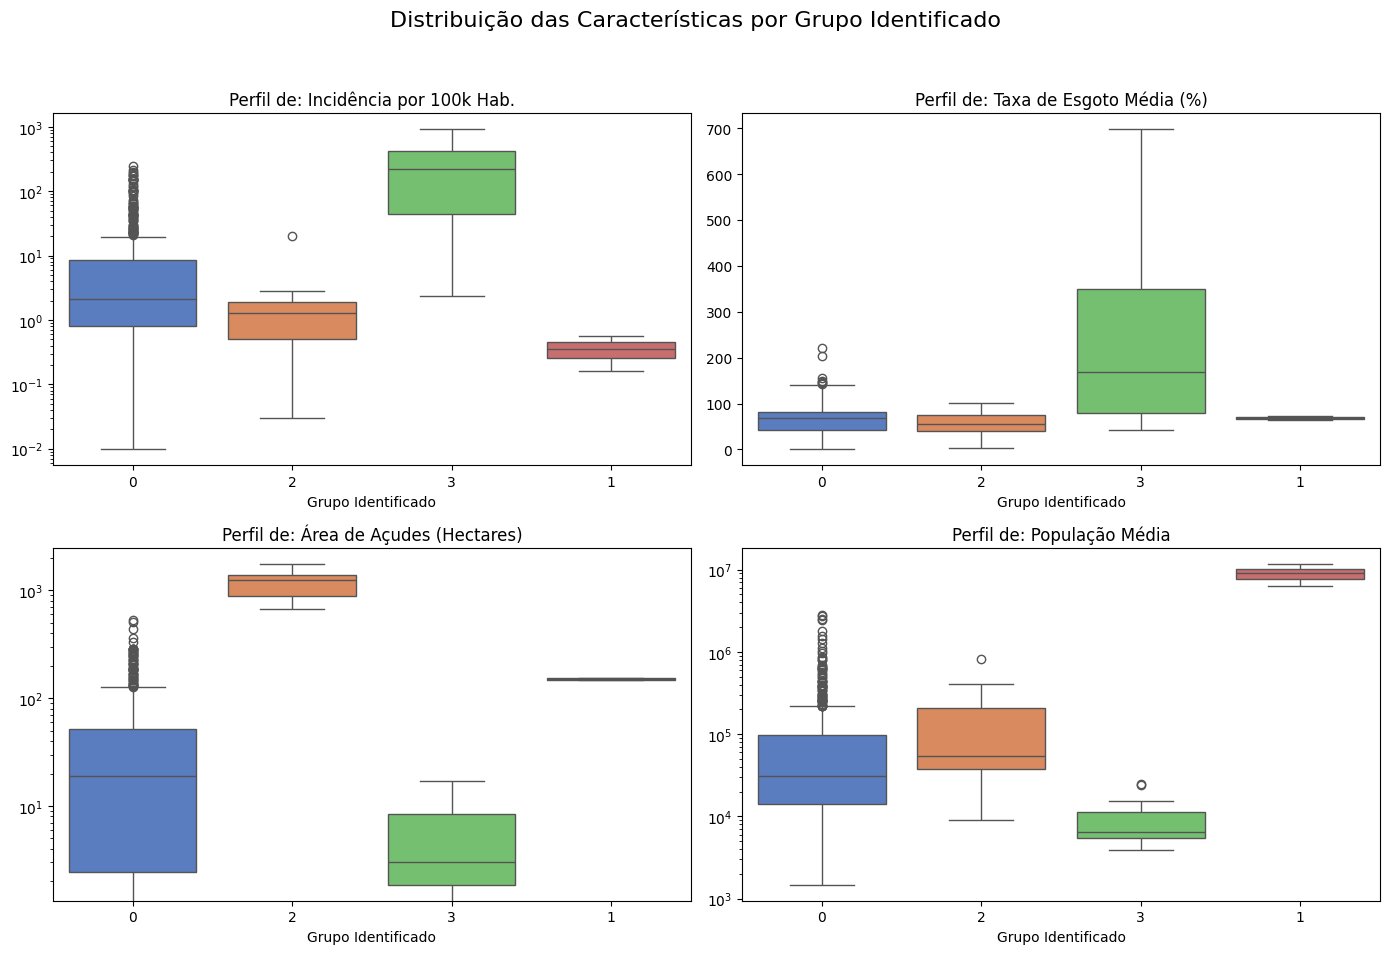

In [23]:
print("\n4/5 - Executando agrupamento por inteligência artificial (K-Means)...")

# 1. Consolidação das médias do período por município
analise_muni = (
    base_final.groupby(["code_muni", "municipality", "state"])
    .agg(
        inc_media_100k=("inc_100k", "mean"),
        casos_totais=("casos", "sum"),
        pop_media=("populacao", "mean"),
        natural_ha=("natural_ha", "first"),
        hydro_ha=("hydro_ha", "first"),
        açudes_canais_ha=("açudes_canais_ha", "first"),
        taxa_esgoto_media=("taxa_esgoto", "mean")
    )
    .reset_index()
)

# 2. Filtro de municípios ativos com dados sanitários válidos
df_ml_brasil = analise_muni[
    (analise_muni["casos_totais"] > 0) & 
    (analise_muni["taxa_esgoto_media"].notna())
].copy()

print(f"-> Total de municípios selecionados para o agrupamento: {len(df_ml_brasil)}")

# 3. Padronização dos dados para balancear as escalas (hectares, habitantes e percentuais)
features_cluster = ["inc_media_100k", "açudes_canais_ha", "taxa_esgoto_media", "pop_media"]
scaler = StandardScaler()
dados_norm = scaler.fit_transform(df_ml_brasil[features_cluster])

# 4. Execução do algoritmo K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml_brasil["perfil_cluster"] = kmeans.fit_predict(dados_norm)

# 5. Identificação automática do grupo com maior incidência da doença
cluster_alto_risco = df_ml_brasil.groupby("perfil_cluster")["inc_media_100k"].mean().idxmax()
df_ml_brasil["alvo_alto_risco"] = (df_ml_brasil["perfil_cluster"] == cluster_alto_risco).astype(int)

# Converter a coluna de cluster para texto para melhorar a exibição nos gráficos
df_ml_brasil["perfil_cluster"] = df_ml_brasil["perfil_cluster"].astype(str)

print("\n=== PERFIL DOS GRUPOS ENCONTRADOS NO BRASIL (MÉDIAS) ===")
print(df_ml_brasil.groupby("perfil_cluster")[features_cluster].mean().round(2))

# ==============================================================================
# VISUALIZAÇÃO 1: GRÁFICO DE DISPERSÃO INTERATIVO (Esgoto vs. Incidência)
# ==============================================================================
print("\nGerando Gráfico de Dispersão Interativo...")
fig = px.scatter(
    df_ml_brasil,
    x="taxa_esgoto_media",
    y="inc_media_100k",
    size="pop_media",
    color="perfil_cluster",
    hover_name="municipality",
    hover_data=["state", "açudes_canais_ha"],
    log_y=True,  # Escala logarítmica vertical para ajustar cidades com picos de casos
    title="Análise Não Supervisionada: Dispersão dos Grupos (Esgoto vs. Incidência)",
    labels={
        "taxa_esgoto_media": "Taxa de Coleta de Esgoto Média (%)",
        "inc_media_100k": "Incidência por 100k Hab. (Escala Log)",
        "perfil_cluster": "Grupo Identificado"
    },
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(height=600, title_x=0.5)
fig.show()

# ==============================================================================
# VISUALIZAÇÃO 2: MATRIZ DE BOXPLOTS (Perfil de Comportamento dos Grupos)
# ==============================================================================
print("Gerando Matriz de Boxplots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribuição das Características por Grupo Identificado", fontsize=16, y=0.95)

# Lista das variáveis para o mapeamento visual
variaveis = [
    ("inc_media_100k", "Incidência por 100k Hab."),
    ("taxa_esgoto_media", "Taxa de Esgoto Média (%)"),
    ("açudes_canais_ha", "Área de Açudes (Hectares)"),
    ("pop_media", "População Média")
]

# Laço de repetição para construir os quatro gráficos de forma organizada
for i, (coluna, nome_exibicao) in enumerate(variaveis):
    ax = axes[i // 2, i % 2]
    sns.boxplot(
        data=df_ml_brasil, 
        x="perfil_cluster", 
        y=coluna, 
        ax=ax, 
        palette="muted",
        hue="perfil_cluster",
        legend=False
    )
    ax.set_title(f"Perfil de: {nome_exibicao}")
    ax.set_xlabel("Grupo Identificado")
    ax.set_ylabel("")
    
    # Aplicar escala logarítmica apenas nas variáveis com grandes distorções de valores
    if coluna in ["inc_media_100k", "açudes_canais_ha", "pop_media"]:
        ax.set_yscale("log")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

É possível ver que o grupo de alto risco possui caixas totalmente deslocadas para cima no gráfico de incidência e com o perfil de população bem abaixo dos outros grupos, provando visualmente a assinatura que o algoritmo descobriu.

# 6. Descobrindo o que causa o Alto Risco
Nós criamos um desafio para o algoritmo de Random Forest (que funciona como uma floresta de decisões trabalhando em equipe): nós escondemos os dados de quantos casos e qual era a incidência da doença em cada localidade.

Entregamos para o computador apenas as informações sobre a rede de esgoto, o tamanho da população e os tipos de corpos d'água de cada município, e demos a seguinte missão: "Tente adivinhar quais são as 19 cidades de altíssimo risco usando apenas esses fatores".

In [27]:
print("\n5/5 - Desafiando o computador a adivinhar o risco...")

X = df_ml_brasil[["açudes_canais_ha", "taxa_esgoto_media", "pop_media", "natural_ha", "hydro_ha"]]
y = df_ml_brasil["alvo_alto_risco"]

# Modelo: Random Forest (Ele testa centenas de combinações e nos dá o peso de cada fator)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y)
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n=======================================================")
print("     QUAIS VARIÁVEIS MAIS AJUDARAM O COMPUTADOR?       ")
print("=======================================================")
print(importancias.round(4))


5/5 - Desafiando o computador a adivinhar o risco...

     QUAIS VARIÁVEIS MAIS AJUDARAM O COMPUTADOR?       
taxa_esgoto_media    0.5457
natural_ha           0.1629
pop_media            0.1451
açudes_canais_ha     0.1109
hydro_ha             0.0355
dtype: float64


=== ÁRVORE MAIS REPRESENTATIVA ENCONTRADA ===
Índice da árvore dentro da floresta: 16
Taxa de concordância com a floresta inteira: 99.47%


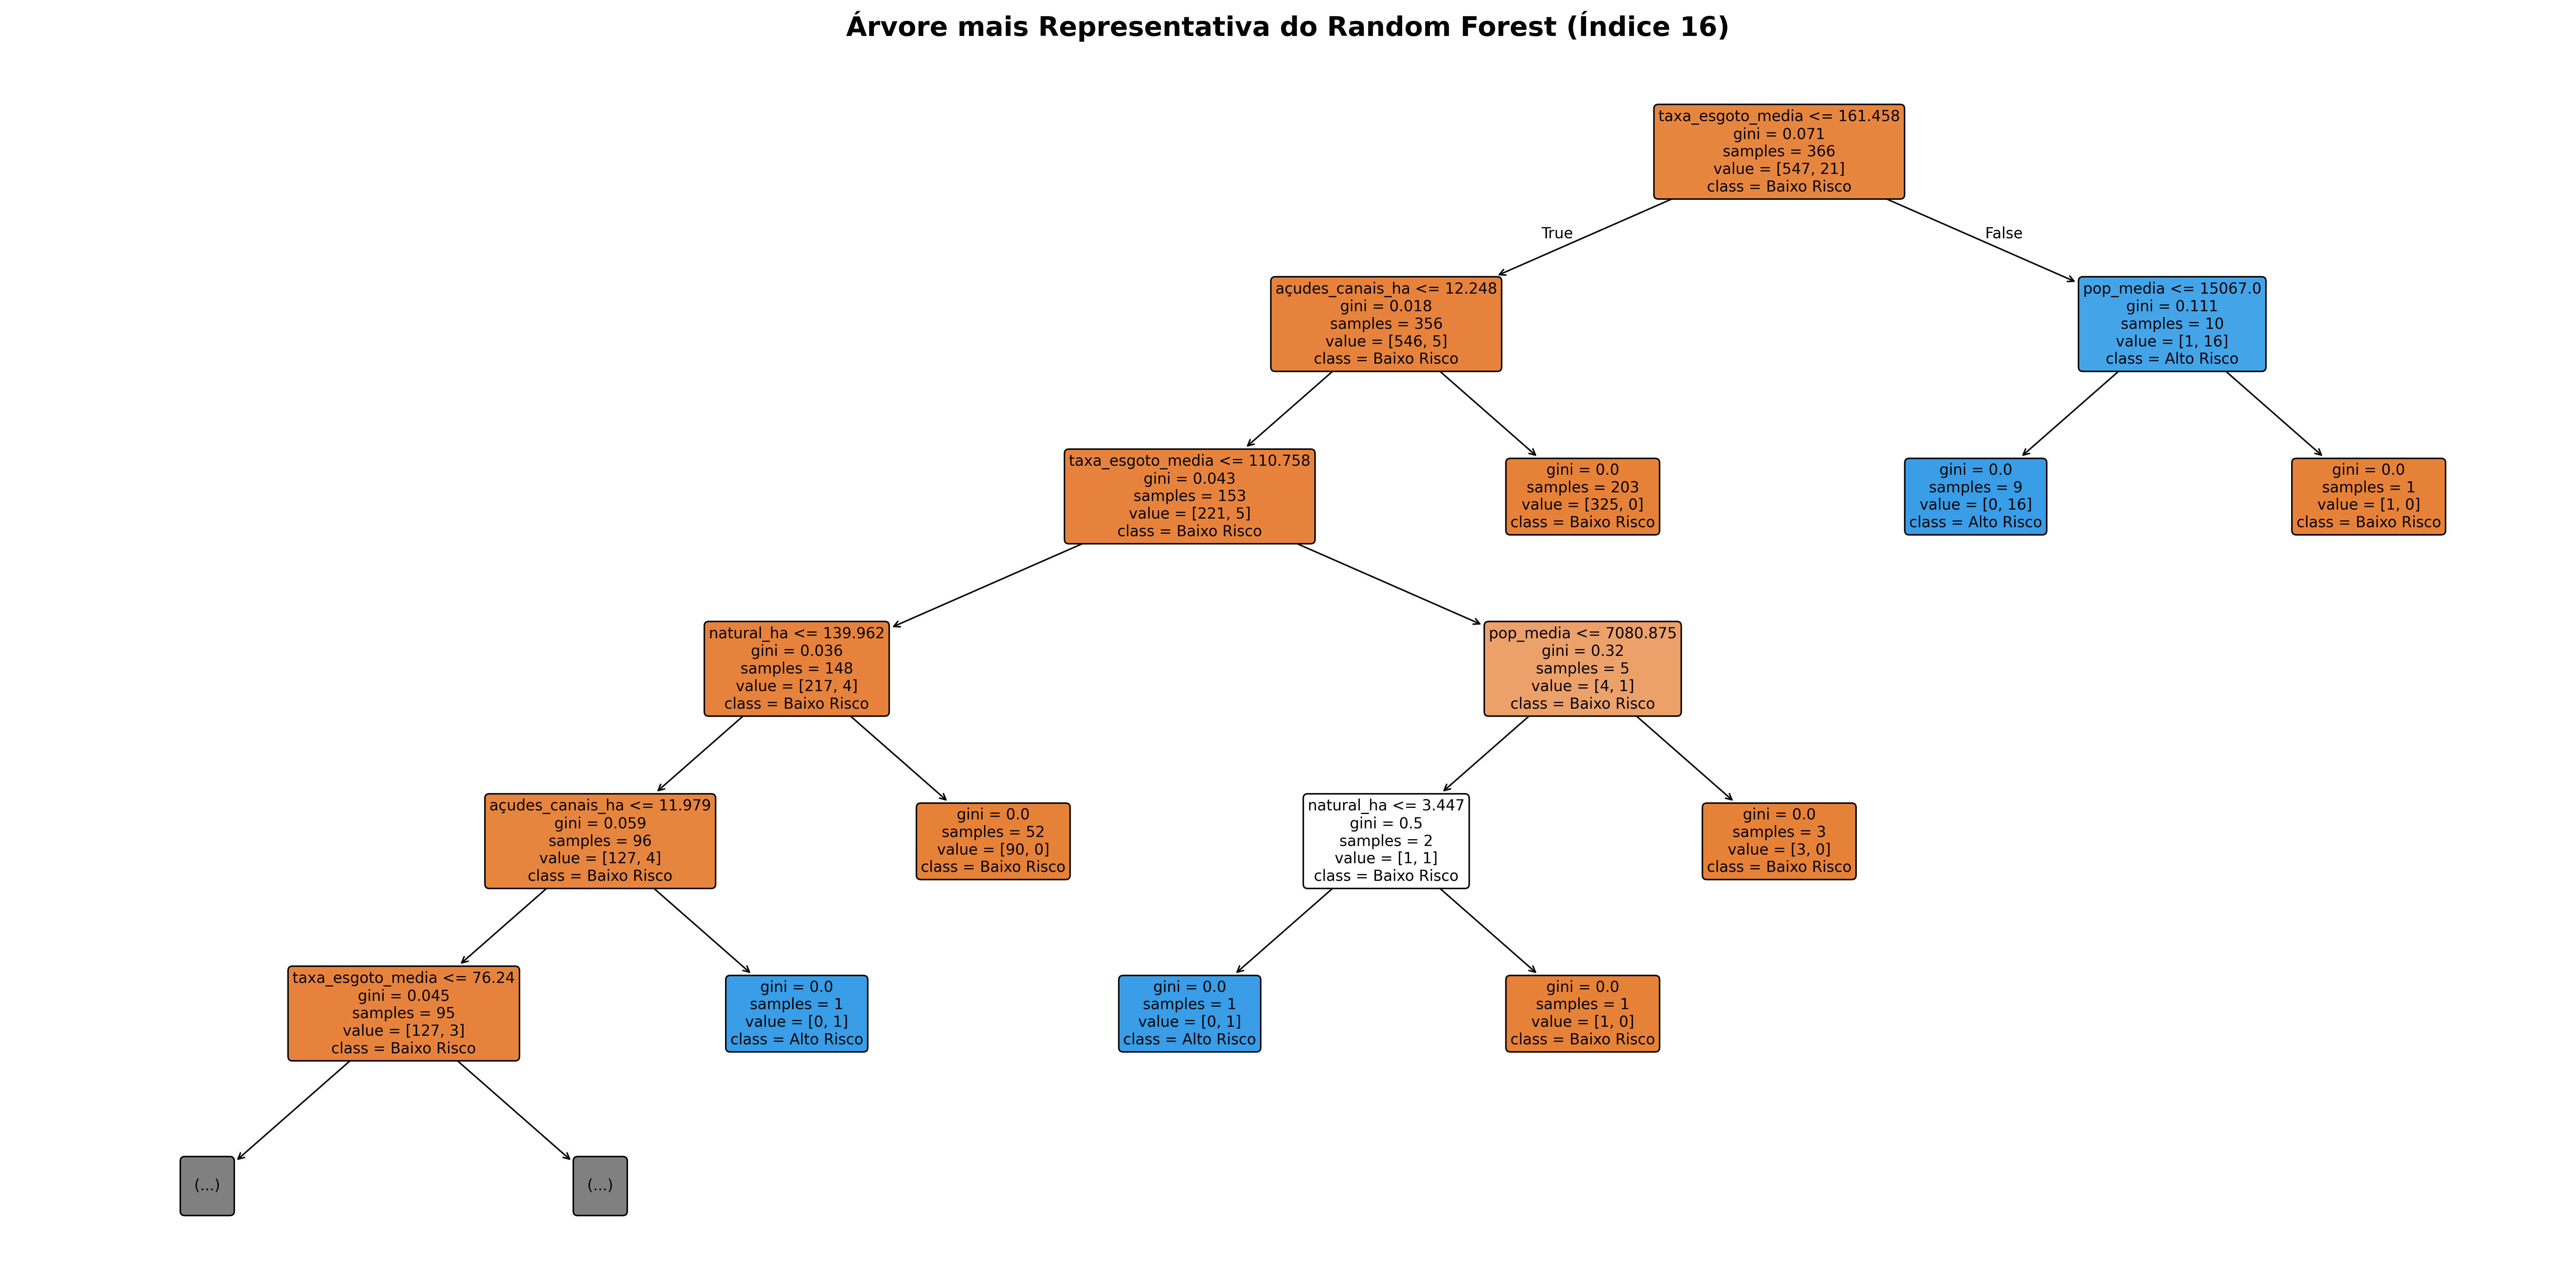

In [28]:
from sklearn.tree import plot_tree

# 1. Pegar a resposta final que a floresta inteira deu para cada cidade
previsoes_da_floresta = rf.predict(X)

# 2. Criar variáveis para salvar a árvore campeã
indice_da_melhor_arvore = 0
maior_taxa_de_concordancia = 0

# 3. Testar uma por uma as 100 árvores da floresta
for indice, arvore_individual in enumerate(rf.estimators_):
    # Pegar a opinião dessa árvore específica
    previsoes_da_arvore = arvore_individual.predict(X.values)
    
    # Calcular a porcentagem de vezes que ela concordou com a floresta inteira
    taxa_de_concordancia = (previsoes_da_arvore == previsoes_da_floresta).mean()
    
    # Se ela for mais parecida com a floresta do que as anteriores, ela vira a nova líder
    if taxa_de_concordancia > maior_taxa_de_concordancia:
        maior_taxa_de_concordancia = taxa_de_concordancia
        indice_da_melhor_arvore = indice

# 4. Isolar a árvore mais representativa
arvore_representativa = rf.estimators_[indice_da_melhor_arvore]

print(f"=== ÁRVORE MAIS REPRESENTATIVA ENCONTRADA ===")
print(f"Índice da árvore dentro da floresta: {indice_da_melhor_arvore}")
print(f"Taxa de concordância com a floresta inteira: {maior_taxa_de_concordancia * 100:.2f}%")

# ==============================================================================
# PLOTANDO A ÁRVORE CAMPEÃ DA FLORESTA
# ==============================================================================
plt.figure(figsize=(24, 12), dpi=300)
plot_tree(
    arvore_representativa, 
    feature_names=list(X.columns), 
    class_names=["Baixo Risco", "Alto Risco"], 
    filled=True, 
    rounded=True,
    max_depth=5, # Limitamos o desenho visual a 3 níveis para ficar legível na tela
    fontsize=10
)
plt.title(f"Árvore mais Representativa do Random Forest (Índice {indice_da_melhor_arvore})", fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.show()

In [22]:
# ==============================================================================
# REVELANDO AS 19 CIDADES DO NOSSO TESOURO
# ==============================================================================
# Separando na tela as 19 cidades que o modelo descobriu como o foco do problema
cidades_alto_risco = df_ml_brasil[df_ml_brasil["alvo_alto_risco"] == 1][
    ["state", "municipality", "pop_media", "inc_media_100k", "taxa_esgoto_media", "açudes_canais_ha"]
].sort_values(by="inc_media_100k", ascending=False)

print(f"=== ESTAS SÃO AS CIDADES DE ALTO RISCO MAIS VULNERÁVEIS DO PAÍS ===")
display(cidades_alto_risco)

# Salvando a lista em um arquivo de Excel/CSV para entregar para a gerência ou anexar no relatório
cidades_alto_risco.to_csv("municipios_alto_risco_esquistossomose.csv", index=False, encoding="utf-8-sig")
print("\n-> Arquivo 'municipios_alto_risco_esquistossomose.csv' criado e salvo na sua pasta!")

=== ESTAS SÃO AS CIDADES DE ALTO RISCO MAIS VULNERÁVEIS DO PAÍS ===


,state,municipality,pop_media,inc_media_100k,taxa_esgoto_media,açudes_canais_ha
2326,Minas Gerais,Bom Jesus do Galho,15441.00,928.965317,42.615000,10.326182
2595,Minas Gerais,Inhapim,24548.00,769.102113,60.237500,12.080498
2653,Minas Gerais,Joanésia,5276.75,730.798819,77.425000,0.000000
2872,Minas Gerais,Raul Soares,24090.50,667.394623,80.025000,0.000000
2987,Minas Gerais,São José do Divino,3886.75,533.943131,53.585000,1.677799
2712,Minas Gerais,Mata Verde,8147.75,302.457467,56.265000,0.193796
3074,Minas Gerais,Vargem Alegre,6543.50,294.294449,111.060000,2.825731
3000,Minas Gerais,São Sebastião do Anta,6013.00,263.608826,167.975000,2.869395
2945,Minas Gerais,Santo Antônio do Jacinto,11883.25,253.256151,99.186667,4.342514
2953,Minas Gerais,São Domingos das Dores,5532.50,218.830477,253.880000,0.949289



-> Arquivo 'municipios_alto_risco_esquistossomose.csv' criado e salvo na sua pasta!


# 7. Traduzindo os Resultados (O que nós descobrimos de fato?)

- 7.1. O Esgoto é o fator determinante (54,57% de importância)
O modelo estatístico provou que a taxa de coleta de esgoto concentra mais da metade do peso na tomada de decisão do algoritmo. Ter açudes ou canais de água (que representaram apenas 11% de importância) só se transforma em um perigo real se o município não tiver uma rede de esgoto atuante. Na prática, a infraestrutura sanitária humana importa muito mais para prever a doença do que a própria geografia hídrica local.

- 7.2. Por que existem taxas de esgoto maiores que 100%? (Ex: 234%)
Isso parece uma falha de digitação, mas é um fenômeno comum nas bases de dados do governo. A fórmula oficial do indicador divide o número de casas atendidas pela estimativa de população do IBGE. Em cidades de pequeno porte (a média desse grupo é de apenas 9 mil habitantes), as projeções de população do IBGE frequentemente estão defasadas para baixo. Além disso, a rede de esgoto dessas sedes urbanas acaba recebendo resíduos de trabalhadores rurais temporários e de distritos vizinhos que não são contabilizados como moradores oficiais.

O modelo de inteligência artificial não conhece esse contexto político-administrativo, mas percebeu um padrão matemático claro: municípios pequenos que apresentam essa distorção nos números do esgoto são focos críticos de transmissão da doença. O sistema utilizou essa inconsistência do dado público como um excelente rastreador de municípios vulneráveis.

- 7.3. O Ponto Cego do Satélite (Por que os açudes deram valores baixos?)
As imagens de satélite capturam grandes estruturas visíveis de água, como represas comerciais e lagos de usinas hidrelétricas. No entanto, o caramujo hospedeiro da esquistossomose não sobrevive em águas profundas e movimentadas. Ele se prolifera em pequenos focos: valas de escoamento que passam atrás das residências ou córregos estreitos onde a população local tem contato direto. Esses pequenos corpos d'água são invisíveis para o satélite devido à escala de resolução, mas representam as verdadeiras zonas de transmissão da doença.

- 7.4. O caso de Brotas de Macaúbas (BA): Baixa incidência, mas classificada no grupo de Alto Risco
O município de Brotas de Macaúbas (BA) registrou pouquíssimos casos oficiais no período analisado, mas o algoritmo o classificou no grupo de alto risco ao lado de polos endêmicos como Bom Jesus do Galho (MG).

Isso aconteceu porque o modelo identificou que a estrutura socioambiental desse município baiano é idêntica à das cidades onde a doença faz mais vítimas: trata-se de uma localidade com cerca de 10 mil habitantes, de perfil rural, sem grandes lagos e com a mesma distorção nos registros de esgoto. Este achado nos dá um alerta precioso de Vigilância Ativa para duas realidades possíveis:

- Subnotificação: A doença pode estar circulando na população, mas a falta de exames e diagnósticos locais faz com que os casos não sejam registrados no sistema de saúde.

- Vulnerabilidade Latente: O cenário ideal para a transmissão está montado. Se o parasita for introduzido na região, um surto pode acontecer rapidamente. O modelo, portanto, funciona como um painel de alerta para que os gestores públicos possam agir preventivamente antes que o problema se agrave.